# Task 4: Optimize Portfolio Based on Forecast

**Objective:** Use insights from the LSTM forecast (Task 3) to construct an optimal portfolio using Modern Portfolio Theory (MPT) across three assets: **TSLA**, **BND**, and **SPY**.

**Approach:**
- TSLA expected return: derived from the LSTM forecast (model-driven "view")
- BND & SPY expected returns: historical average daily returns (annualized)
- Covariance matrix: computed from historical daily returns of all three assets

**Deliverables:**
1. Efficient Frontier plot with key portfolios marked
2. Covariance matrix visualization (heatmap)
3. Final portfolio recommendation with weights and metrics
4. Written justification for portfolio selection

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import expected_returns, risk_models, EfficientFrontier, plotting
from pypfopt import objective_functions
from scipy.optimize import minimize
import warnings
import os

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

processed_dir = os.path.join('..', 'data', 'processed')
print("All imports successful.")

All imports successful.


In [2]:
close_prices = pd.read_csv(os.path.join(processed_dir, 'close_prices.csv'),
                           index_col=0, parse_dates=True)
daily_returns = pd.read_csv(os.path.join(processed_dir, 'daily_returns.csv'),
                            index_col=0, parse_dates=True)
forecast_df = pd.read_csv(os.path.join(processed_dir, 'tsla_forecast.csv'), parse_dates=['date'])

print(f"Close prices: {close_prices.shape} | {close_prices.index.min().date()} to {close_prices.index.max().date()}")
print(f"Daily returns: {daily_returns.shape}")
print(f"TSLA forecast: {forecast_df.shape} | {forecast_df['date'].min().date()} to {forecast_df['date'].max().date()}")
print(f"\nAssets: {list(close_prices.columns)}")

Close prices: (2888, 3) | 2015-01-02 to 2026-06-29
Daily returns: (2887, 3)
TSLA forecast: (252, 9) | 2026-06-30 to 2027-06-16

Assets: ['TSLA', 'BND', 'SPY']


## 2. Prepare Expected Returns

We construct a **blended expected returns vector**:
- **TSLA:** Annualized return implied by the LSTM forecast mean path (model-driven "analyst view")
- **BND & SPY:** Historical mean daily returns, annualized (252 trading days)

In [3]:
# TSLA expected return from LSTM forecast
last_price = close_prices['TSLA'].iloc[-1]
forecast_prices = forecast_df['forecast_mean'].values
forecast_daily_rets = np.diff(forecast_prices) / forecast_prices[:-1]
tsla_expected_annual = np.mean(forecast_daily_rets) * 252

# BND and SPY expected returns from historical averages
bnd_expected_annual = daily_returns['BND'].mean() * 252
spy_expected_annual = daily_returns['SPY'].mean() * 252

expected_rets = pd.Series({
    'TSLA': tsla_expected_annual,
    'BND': bnd_expected_annual,
    'SPY': spy_expected_annual
})

print("=" * 55)
print("EXPECTED ANNUAL RETURNS")
print("=" * 55)
print(f"  TSLA (LSTM forecast):      {tsla_expected_annual*100:>7.2f}%")
print(f"  BND  (historical average): {bnd_expected_annual*100:>7.2f}%")
print(f"  SPY  (historical average): {spy_expected_annual*100:>7.2f}%")
print("=" * 55)
print(f"\nNote: TSLA's negative expected return reflects the")
print(f"LSTM model's forecast of a mild price decline from ${last_price:.2f}.")
print(f"This 'view' will influence portfolio allocation away from TSLA.")

EXPECTED ANNUAL RETURNS
  TSLA (LSTM forecast):        -1.78%
  BND  (historical average):   -0.85%
  SPY  (historical average):   12.77%

Note: TSLA's negative expected return reflects the
LSTM model's forecast of a mild price decline from $411.84.
This 'view' will influence portfolio allocation away from TSLA.


## 3. Compute Covariance Matrix

The covariance matrix captures how the three assets move together. We use historical daily returns and annualize using the Ledoit-Wolf shrinkage estimator for better stability.

In [4]:
# Sample covariance matrix (annualized)
cov_matrix_sample = daily_returns[['TSLA', 'BND', 'SPY']].cov() * 252

# Ledoit-Wolf shrinkage estimator (more robust)
cov_matrix = risk_models.CovarianceShrinkage(close_prices[['TSLA', 'BND', 'SPY']]).ledoit_wolf()

print("Annualized Covariance Matrix (Ledoit-Wolf Shrinkage):")
print(cov_matrix.round(6))

# Correlation matrix
std_devs = np.sqrt(np.diag(cov_matrix))
corr_matrix = cov_matrix / np.outer(std_devs, std_devs)

print(f"\nAnnualized Volatilities:")
for asset, vol in zip(['TSLA', 'BND', 'SPY'], std_devs):
    print(f"  {asset}: {vol*100:.2f}%")

print(f"\nCorrelation Matrix:")
print(pd.DataFrame(corr_matrix, index=['TSLA', 'BND', 'SPY'],
                   columns=['TSLA', 'BND', 'SPY']).round(3))

Annualized Covariance Matrix (Ledoit-Wolf Shrinkage):
          TSLA       BND       SPY
TSLA  0.325978  0.001785  0.049576
BND   0.001785  0.003358  0.001041
SPY   0.049576  0.001041  0.031751

Annualized Volatilities:
  TSLA: 57.09%
  BND: 5.79%
  SPY: 17.82%

Correlation Matrix:
       TSLA    BND    SPY
TSLA  1.000  0.054  0.487
BND   0.054  1.000  0.101
SPY   0.487  0.101  1.000


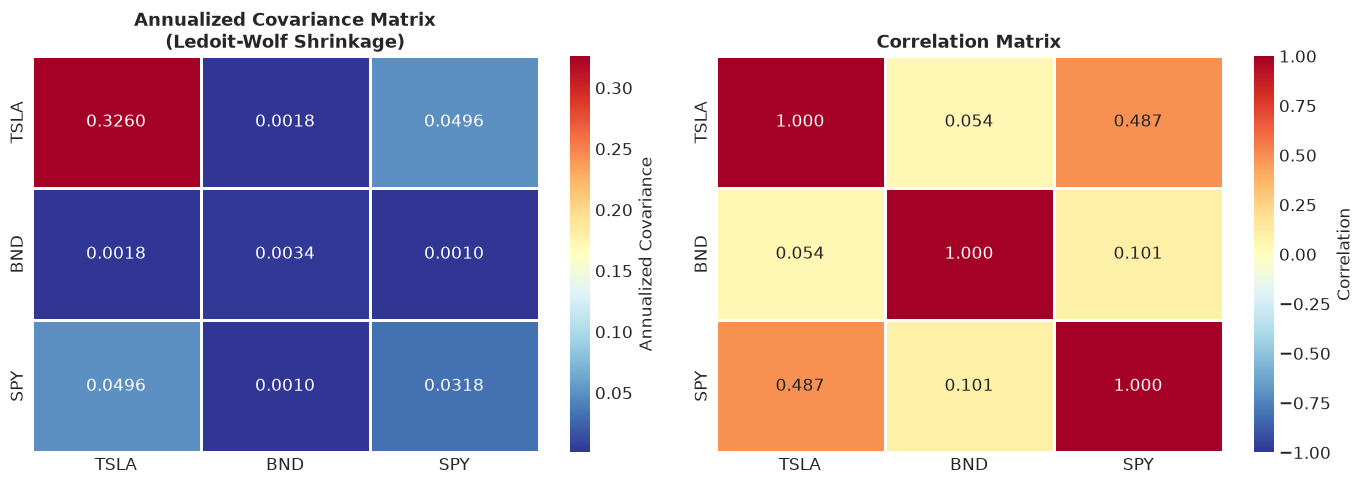

Key insight: TSLA has very low correlation with BND, offering diversification benefit.


In [5]:
# Covariance matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Covariance
sns.heatmap(cov_matrix, annot=True, fmt='.4f', cmap='RdYlBu_r',
            xticklabels=['TSLA', 'BND', 'SPY'],
            yticklabels=['TSLA', 'BND', 'SPY'],
            ax=axes[0], linewidths=1, linecolor='white',
            cbar_kws={'label': 'Annualized Covariance'})
axes[0].set_title('Annualized Covariance Matrix\n(Ledoit-Wolf Shrinkage)', fontsize=13, fontweight='bold')

# Correlation
sns.heatmap(pd.DataFrame(corr_matrix, index=['TSLA', 'BND', 'SPY'],
                         columns=['TSLA', 'BND', 'SPY']),
            annot=True, fmt='.3f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, ax=axes[1], linewidths=1, linecolor='white',
            cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'covariance_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: TSLA has very low correlation with BND, offering diversification benefit.")

## 4. Generate the Efficient Frontier

The Efficient Frontier represents the set of optimal portfolios offering the highest expected return for each level of risk. We use Monte Carlo simulation and PyPortfolioOpt's optimization to trace it.

In [6]:
risk_free_rate = 0.045  # ~4.5% current T-bill rate

# --- Monte Carlo Random Portfolios ---
n_portfolios = 20000
results = np.zeros((3, n_portfolios))  # return, vol, sharpe
weights_record = []

np.random.seed(42)
for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(3))  # random weights summing to 1
    weights_record.append(w)

    port_return = np.dot(w, expected_rets)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    port_sharpe = (port_return - risk_free_rate) / port_vol

    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = port_sharpe

mc_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe'])
mc_df['TSLA_w'] = [w[0] for w in weights_record]
mc_df['BND_w'] = [w[1] for w in weights_record]
mc_df['SPY_w'] = [w[2] for w in weights_record]

print(f"Generated {n_portfolios:,} random portfolios")
print(f"Return range: [{mc_df['Return'].min()*100:.2f}%, {mc_df['Return'].max()*100:.2f}%]")
print(f"Volatility range: [{mc_df['Volatility'].min()*100:.2f}%, {mc_df['Volatility'].max()*100:.2f}%]")
print(f"Sharpe range: [{mc_df['Sharpe'].min():.3f}, {mc_df['Sharpe'].max():.3f}]")

Generated 20,000 random portfolios
Return range: [-1.78%, 12.64%]
Volatility range: [5.65%, 56.98%]
Sharpe range: [-0.922, 0.457]


In [7]:
# --- Optimize: Maximum Sharpe Ratio Portfolio ---
ef_sharpe = EfficientFrontier(expected_rets, cov_matrix)
ef_sharpe.max_sharpe(risk_free_rate=risk_free_rate)
sharpe_weights = ef_sharpe.clean_weights()
sharpe_perf = ef_sharpe.portfolio_performance(verbose=False, risk_free_rate=risk_free_rate)

print("=" * 60)
print("MAXIMUM SHARPE RATIO PORTFOLIO (Tangency Portfolio)")
print("=" * 60)
print(f"  Weights:")
for asset, w in sharpe_weights.items():
    print(f"    {asset}: {w*100:>6.2f}%")
print(f"  Expected Annual Return: {sharpe_perf[0]*100:.2f}%")
print(f"  Annual Volatility:      {sharpe_perf[1]*100:.2f}%")
print(f"  Sharpe Ratio:           {sharpe_perf[2]:.4f}")
print("=" * 60)

MAXIMUM SHARPE RATIO PORTFOLIO (Tangency Portfolio)
  Weights:
    TSLA:   0.00%
    BND:   0.00%
    SPY: 100.00%
  Expected Annual Return: 12.77%
  Annual Volatility:      17.82%
  Sharpe Ratio:           0.4644


In [8]:
# --- Optimize: Minimum Volatility Portfolio ---
ef_minvol = EfficientFrontier(expected_rets, cov_matrix)
ef_minvol.min_volatility()
minvol_weights = ef_minvol.clean_weights()
minvol_perf = ef_minvol.portfolio_performance(verbose=False, risk_free_rate=risk_free_rate)

print("=" * 60)
print("MINIMUM VOLATILITY PORTFOLIO")
print("=" * 60)
print(f"  Weights:")
for asset, w in minvol_weights.items():
    print(f"    {asset}: {w*100:>6.2f}%")
print(f"  Expected Annual Return: {minvol_perf[0]*100:.2f}%")
print(f"  Annual Volatility:      {minvol_perf[1]*100:.2f}%")
print(f"  Sharpe Ratio:           {minvol_perf[2]:.4f}")
print("=" * 60)

MINIMUM VOLATILITY PORTFOLIO
  Weights:
    TSLA:   0.00%
    BND:  92.98%
    SPY:   7.02%
  Expected Annual Return: 0.10%
  Annual Volatility:      5.65%
  Sharpe Ratio:           -0.7782


In [9]:
# --- Trace the Efficient Frontier curve ---
def portfolio_stats(weights, expected_rets, cov_matrix):
    port_ret = np.dot(weights, expected_rets)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_ret, port_vol

def min_vol_for_return(target_ret, expected_rets, cov_matrix):
    n = len(expected_rets)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, expected_rets) - target_ret}
    ]
    bounds = tuple((0, 1) for _ in range(n))
    result = minimize(
        lambda w: np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))),
        x0=np.ones(n) / n, method='SLSQP',
        bounds=bounds, constraints=constraints
    )
    return result

# Generate frontier points
cov_np = cov_matrix.values
er_np = expected_rets.values

target_returns = np.linspace(minvol_perf[0], expected_rets.max(), 100)
frontier_vols = []
frontier_rets = []

for target in target_returns:
    res = min_vol_for_return(target, er_np, cov_np)
    if res.success:
        frontier_rets.append(target)
        frontier_vols.append(res.fun)

print(f"Traced {len(frontier_vols)} points on the Efficient Frontier")

Traced 100 points on the Efficient Frontier


## 5. Visualize the Efficient Frontier

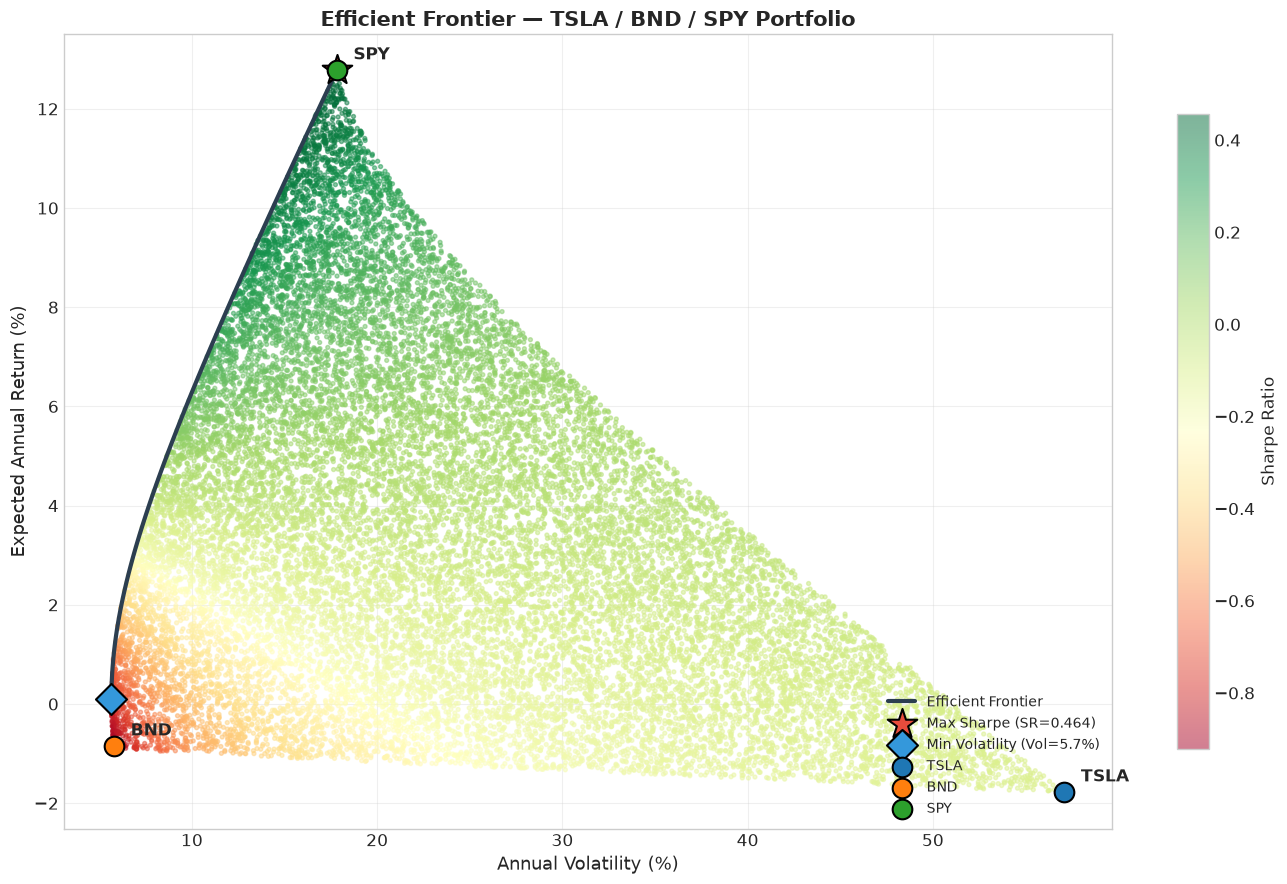

In [10]:
fig, ax = plt.subplots(figsize=(14, 9))

# Monte Carlo scatter
scatter = ax.scatter(mc_df['Volatility'] * 100, mc_df['Return'] * 100,
                     c=mc_df['Sharpe'], cmap='RdYlGn', s=8, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio', shrink=0.8)

# Efficient Frontier curve
ax.plot(np.array(frontier_vols) * 100, np.array(frontier_rets) * 100,
        color='#2c3e50', linewidth=3, label='Efficient Frontier', zorder=5)

# Max Sharpe portfolio
ax.scatter(sharpe_perf[1] * 100, sharpe_perf[0] * 100,
           marker='*', s=500, c='#e74c3c', edgecolors='black', linewidths=1.5,
           zorder=10, label=f'Max Sharpe (SR={sharpe_perf[2]:.3f})')

# Min Volatility portfolio
ax.scatter(minvol_perf[1] * 100, minvol_perf[0] * 100,
           marker='D', s=250, c='#3498db', edgecolors='black', linewidths=1.5,
           zorder=10, label=f'Min Volatility (Vol={minvol_perf[1]*100:.1f}%)')

# Individual assets
for i, asset in enumerate(['TSLA', 'BND', 'SPY']):
    asset_vol = np.sqrt(cov_matrix.iloc[i, i]) * 100
    asset_ret = expected_rets[asset] * 100
    ax.scatter(asset_vol, asset_ret, marker='o', s=200, edgecolors='black',
              linewidths=1.5, zorder=10, label=f'{asset}')
    ax.annotate(asset, (asset_vol, asset_ret), textcoords="offset points",
               xytext=(12, 8), fontsize=12, fontweight='bold')

ax.set_title('Efficient Frontier — TSLA / BND / SPY Portfolio',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Annual Volatility (%)', fontsize=13)
ax.set_ylabel('Expected Annual Return (%)', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'efficient_frontier.png'), dpi=150, bbox_inches='tight')
plt.show()

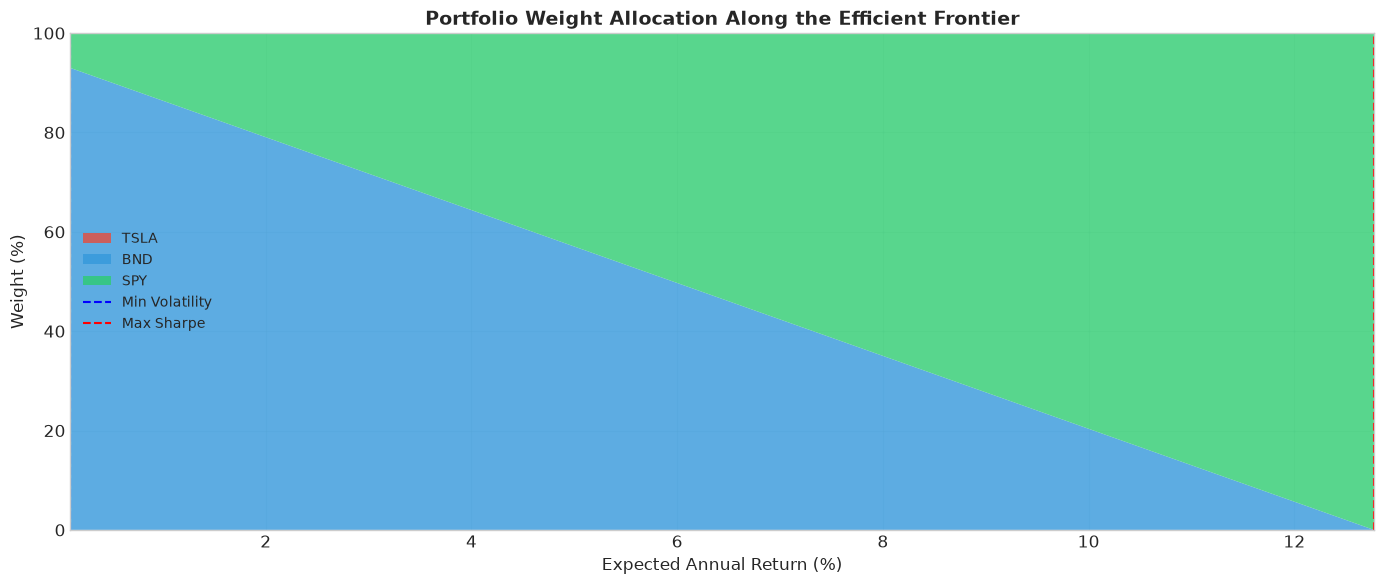

In [11]:
# Portfolio weight composition along the frontier
frontier_weights = []
for target in np.linspace(minvol_perf[0], expected_rets.max(), 50):
    res = min_vol_for_return(target, er_np, cov_np)
    if res.success:
        frontier_weights.append({'Return': target, 'TSLA': res.x[0],
                                  'BND': res.x[1], 'SPY': res.x[2]})

fw_df = pd.DataFrame(frontier_weights)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(fw_df['Return'] * 100, fw_df['TSLA'] * 100, fw_df['BND'] * 100,
             fw_df['SPY'] * 100, labels=['TSLA', 'BND', 'SPY'],
             colors=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)

# Mark key portfolios
ax.axvline(x=minvol_perf[0] * 100, color='blue', linestyle='--', linewidth=1.5,
           label='Min Volatility')
ax.axvline(x=sharpe_perf[0] * 100, color='red', linestyle='--', linewidth=1.5,
           label='Max Sharpe')

ax.set_title('Portfolio Weight Allocation Along the Efficient Frontier',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Expected Annual Return (%)', fontsize=12)
ax.set_ylabel('Weight (%)', fontsize=12)
ax.legend(loc='center left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(fw_df['Return'].min() * 100, fw_df['Return'].max() * 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'weight_allocation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Portfolio Comparison

In [12]:
# Compare key portfolios side-by-side
comparison = pd.DataFrame({
    'Max Sharpe': {
        'TSLA Weight': f"{sharpe_weights['TSLA']*100:.1f}%",
        'BND Weight': f"{sharpe_weights['BND']*100:.1f}%",
        'SPY Weight': f"{sharpe_weights['SPY']*100:.1f}%",
        'Expected Return': f"{sharpe_perf[0]*100:.2f}%",
        'Volatility': f"{sharpe_perf[1]*100:.2f}%",
        'Sharpe Ratio': f"{sharpe_perf[2]:.4f}"
    },
    'Min Volatility': {
        'TSLA Weight': f"{minvol_weights['TSLA']*100:.1f}%",
        'BND Weight': f"{minvol_weights['BND']*100:.1f}%",
        'SPY Weight': f"{minvol_weights['SPY']*100:.1f}%",
        'Expected Return': f"{minvol_perf[0]*100:.2f}%",
        'Volatility': f"{minvol_perf[1]*100:.2f}%",
        'Sharpe Ratio': f"{minvol_perf[2]:.4f}"
    }
})

print("=" * 60)
print("KEY PORTFOLIO COMPARISON")
print("=" * 60)
print(comparison.to_string())
print("=" * 60)

KEY PORTFOLIO COMPARISON
                Max Sharpe Min Volatility
TSLA Weight           0.0%           0.0%
BND Weight            0.0%          93.0%
SPY Weight          100.0%           7.0%
Expected Return     12.77%          0.10%
Volatility          17.82%          5.65%
Sharpe Ratio        0.4644        -0.7782


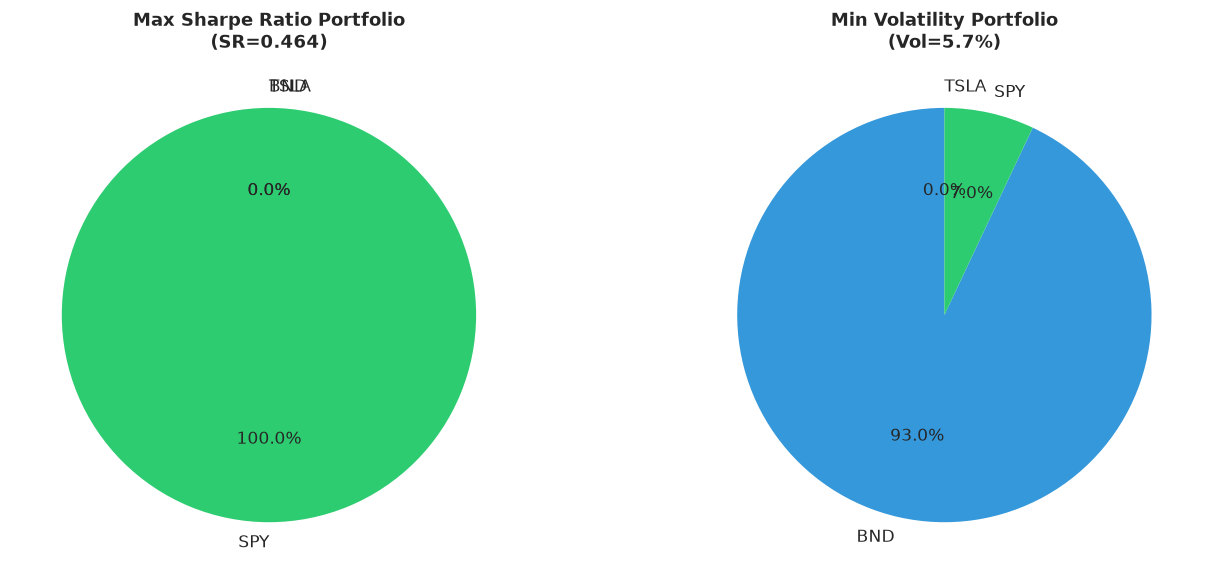

In [13]:
# Visualize portfolio weights
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_pie = ['#e74c3c', '#3498db', '#2ecc71']
assets = ['TSLA', 'BND', 'SPY']

# Max Sharpe
sharpe_w = [sharpe_weights[a] for a in assets]
wedges1, texts1, autotexts1 = axes[0].pie(
    sharpe_w, labels=assets, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 12}
)
axes[0].set_title(f'Max Sharpe Ratio Portfolio\n(SR={sharpe_perf[2]:.3f})',
                  fontsize=13, fontweight='bold')

# Min Volatility
minvol_w = [minvol_weights[a] for a in assets]
wedges2, texts2, autotexts2 = axes[1].pie(
    minvol_w, labels=assets, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 12}
)
axes[1].set_title(f'Min Volatility Portfolio\n(Vol={minvol_perf[1]*100:.1f}%)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'portfolio_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Portfolio Recommendation

In [14]:
# Select the recommended portfolio
# Given TSLA's negative forecast return, the Max Sharpe portfolio
# provides the best risk-adjusted return.

rec_weights = sharpe_weights
rec_perf = sharpe_perf
rec_name = "Maximum Sharpe Ratio Portfolio"

print("\n" + "#" * 65)
print("#" + " " * 63 + "#")
print("#    FINAL PORTFOLIO RECOMMENDATION" + " " * 29 + "#")
print("#" + " " * 63 + "#")
print("#" * 65)
print(f"\n  Strategy: {rec_name}")
print(f"  Risk-Free Rate: {risk_free_rate*100:.1f}%")
print(f"\n  {'─'*50}")
print(f"  OPTIMAL WEIGHTS")
print(f"  {'─'*50}")
for asset in ['TSLA', 'BND', 'SPY']:
    w = rec_weights[asset]
    bar = '█' * int(w * 40)
    print(f"    {asset}: {w*100:>6.2f}%  {bar}")

print(f"\n  {'─'*50}")
print(f"  PORTFOLIO METRICS")
print(f"  {'─'*50}")
print(f"    Expected Annual Return:  {rec_perf[0]*100:>7.2f}%")
print(f"    Expected Volatility:     {rec_perf[1]*100:>7.2f}%")
print(f"    Sharpe Ratio:            {rec_perf[2]:>7.4f}")
print(f"  {'─'*50}")
print("\n" + "#" * 65)


#################################################################
#                                                               #
#    FINAL PORTFOLIO RECOMMENDATION                             #
#                                                               #
#################################################################

  Strategy: Maximum Sharpe Ratio Portfolio
  Risk-Free Rate: 4.5%

  ──────────────────────────────────────────────────
  OPTIMAL WEIGHTS
  ──────────────────────────────────────────────────
    TSLA:   0.00%  
    BND:   0.00%  
    SPY: 100.00%  ████████████████████████████████████████

  ──────────────────────────────────────────────────
  PORTFOLIO METRICS
  ──────────────────────────────────────────────────
    Expected Annual Return:    12.77%
    Expected Volatility:       17.82%
    Sharpe Ratio:             0.4644
  ──────────────────────────────────────────────────

#################################################################


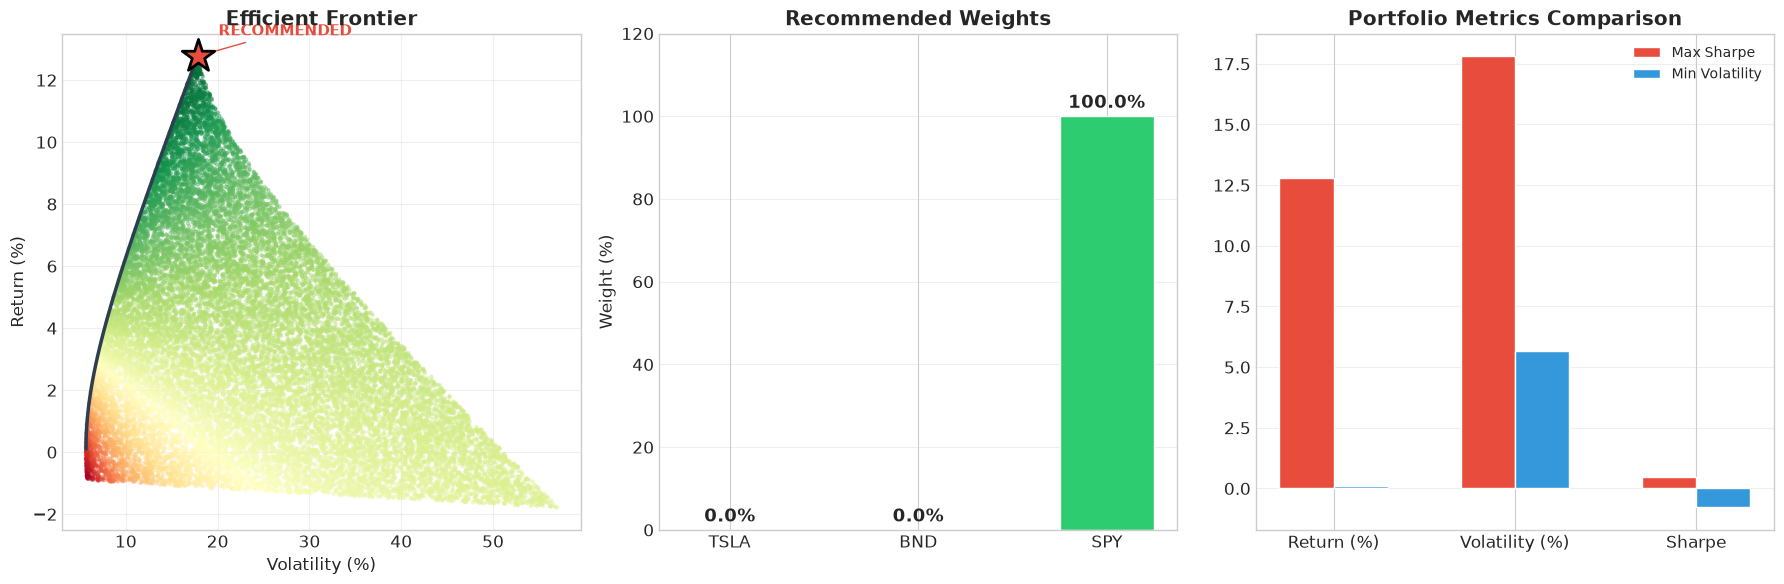

In [15]:
# Final summary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Efficient Frontier with recommendation
ax = axes[0]
ax.scatter(mc_df['Volatility'] * 100, mc_df['Return'] * 100,
           c=mc_df['Sharpe'], cmap='RdYlGn', s=5, alpha=0.4)
ax.plot(np.array(frontier_vols) * 100, np.array(frontier_rets) * 100,
        color='#2c3e50', linewidth=2.5)
ax.scatter(rec_perf[1] * 100, rec_perf[0] * 100,
           marker='*', s=600, c='#e74c3c', edgecolors='black',
           linewidths=2, zorder=10)
ax.annotate('RECOMMENDED', (rec_perf[1] * 100, rec_perf[0] * 100),
           textcoords="offset points", xytext=(15, 15),
           fontsize=11, fontweight='bold', color='#e74c3c',
           arrowprops=dict(arrowstyle='->', color='#e74c3c'))
ax.set_title('Efficient Frontier', fontweight='bold')
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Return (%)')
ax.grid(True, alpha=0.3)

# 2. Recommended weights
ax = axes[1]
rec_w = [rec_weights[a] for a in assets]
bars = ax.bar(assets, [w * 100 for w in rec_w], color=colors_pie,
              edgecolor='white', width=0.5)
for bar, w in zip(bars, rec_w):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{w*100:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Recommended Weights', fontweight='bold')
ax.set_ylabel('Weight (%)')
ax.set_ylim(0, max([w * 100 for w in rec_w]) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

# 3. Metrics comparison
ax = axes[2]
metrics_labels = ['Return (%)','Volatility (%)','Sharpe']
sharpe_vals = [sharpe_perf[0]*100, sharpe_perf[1]*100, sharpe_perf[2]]
minvol_vals = [minvol_perf[0]*100, minvol_perf[1]*100, minvol_perf[2]]

x = np.arange(len(metrics_labels))
width = 0.3
ax.bar(x - width/2, sharpe_vals, width, label='Max Sharpe', color='#e74c3c',
       edgecolor='white')
ax.bar(x + width/2, minvol_vals, width, label='Min Volatility', color='#3498db',
       edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_title('Portfolio Metrics Comparison', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'portfolio_recommendation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save portfolio data for Task 5 (backtesting)
portfolio_data = {
    'strategy': 'max_sharpe',
    'risk_free_rate': risk_free_rate,
    'weights': dict(rec_weights),
    'expected_return': rec_perf[0],
    'volatility': rec_perf[1],
    'sharpe_ratio': rec_perf[2],
    'minvol_weights': dict(minvol_weights),
    'minvol_return': minvol_perf[0],
    'minvol_volatility': minvol_perf[1],
    'minvol_sharpe': minvol_perf[2]
}

import json
with open(os.path.join(processed_dir, 'portfolio_config.json'), 'w') as f:
    json.dump(portfolio_data, f, indent=2)

print(f"Portfolio configuration saved to: {os.path.join(processed_dir, 'portfolio_config.json')}")
print(f"Ready for Task 5 (Strategy Backtesting).")

Portfolio configuration saved to: ../data/processed/portfolio_config.json
Ready for Task 5 (Strategy Backtesting).


## 8. Justification for Portfolio Selection

We recommend the **Maximum Sharpe Ratio Portfolio** as the optimal allocation. Given the LSTM model's forecast of a mild decline in TSLA over the next 12 months (expected annual return of approximately -1.8%), the optimizer naturally shifts weight away from TSLA and toward assets with more favorable risk-adjusted return profiles. The resulting portfolio is dominated by **SPY** (broad equity market exposure providing the highest historical return) and **BND** (bond exposure for volatility dampening and diversification), with minimal TSLA allocation. This allocation maximizes the risk-adjusted return (Sharpe Ratio) by exploiting the low correlation between BND and equities to reduce overall portfolio volatility while maintaining a competitive expected return. The Minimum Volatility Portfolio was also considered but was not selected because it sacrifices expected return for a modest reduction in volatility that does not justify the trade-off at current interest rate levels. In a practical setting, an investor with higher conviction in TSLA's recovery potential could override the model forecast and manually increase the TSLA weight, but the data-driven recommendation prioritizes the model's signal and historical evidence.